<a href="https://colab.research.google.com/github/ebritolbv-cmd/BrazilQuantumCamp/blob/main/QAOA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Implementação do QAOA em PennyLane: Cobertura Mínima de Vértices

---

## Introdução

O **Quantum Approximate Optimization Algorithm (QAOA)** é um algoritmo variacional híbrido quântico-clássico proposto por Farhi, Goldstone e Gutmann em 2014 (arXiv:1411.4028). Ele foi projetado para encontrar **soluções aproximadas** de problemas de otimização combinatória em dispositivos quânticos NISQ (*Noisy Intermediate-Scale Quantum*).

A ideia central do QAOA é mapear um problema de otimização clássico para um **Hamiltoniano de custo** quântico. A solução ótima corresponde ao **estado de menor energia** (autoestado fundamental) desse Hamiltoniano. O algoritmo constrói então um circuito parametrizado que explora o espaço de soluções, e um otimizador clássico ajusta os parâmetros para minimizar a energia esperada.

---

## 1. Instalação e Importações

Antes de começar, precisamos instalar a **PennyLane**, a principal biblioteca de computação quântica diferenciável usada neste notebook. A PennyLane permite construir circuitos quânticos, calcular gradientes e integrar com otimizadores clássicos de forma transparente.

Também usaremos:
- `networkx`: para criar e visualizar grafos
- `matplotlib`: para plotagem dos resultados
- `numpy` (versão PennyLane): para arrays com suporte a diferenciação automática

In [ ]:
# Instalação da PennyLane
# A flag --quiet suprime saídas excessivas durante a instalação
!pip install pennylane --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 78.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 43.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 74.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 70.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 33.0 MB/s eta 0:00:00


In [ ]:
# ============================================================
# Importações principais
# ============================================================

import pennylane as qml
from pennylane import qaoa          # Módulo especializado para QAOA
from pennylane import numpy as np   # NumPy com suporte a autodiferenciação
from matplotlib import pyplot as plt
import networkx as nx

print(f"PennyLane version: {qml.__version__}")

PennyLane version: 0.44.0


---

## 2. Hamiltoniano: Definição e Representação

### O que é um Hamiltoniano?

Em mecânica quântica, o **Hamiltoniano** é o operador que representa a energia total de um sistema e governa sua dinâmica. Em computação quântica, o Hamiltoniano tem um papel mais amplo: ele pode representar não apenas sistemas físicos, mas também **funções objetivo de problemas de otimização**.

### Hamiltoniano no QAOA

No contexto do QAOA, construímos um **Hamiltoniano de custo** $H_C$ que codifica o problema de otimização, de forma que:

- Os **autoestados de menor energia** correspondem às **melhores soluções** do problema.
- Os **coeficientes** dos termos de Pauli representam os pesos da função objetivo e as penalidades de restrições.

### Operadores de Pauli

Um Hamiltoniano quântico é expresso como combinação linear de **operadores de Pauli**:

$$H = \sum_k w_k P_k$$

onde $P_k$ são produtos tensoriais de matrizes de Pauli ($X$, $Y$, $Z$, $I$) e $w_k$ são os coeficientes (pesos) correspondentes.

Em problemas de otimização combinatória com variáveis binárias $x_i \in \{0, 1\}$, a correspondência é feita via:

$$x_i = \frac{1 - Z_i}{2}$$

Isso permite mapear funções de custo clássicas para operadores quânticos.

### Exemplo com `qml.Hamiltonian`

A PennyLane permite criar Hamiltonianos usando a função `qml.Hamiltonian`, onde o usuário especifica os **coeficientes** e os **operadores**.

In [ ]:
# ============================================================
# Exemplo de criação de um Hamiltoniano personalizado
# ============================================================

# qml.Hamiltonian recebe dois argumentos:
# 1) Lista de coeficientes: [1, 1, 0.5]
#    - Cada coeficiente multiplica o operador correspondente
# 2) Lista de operadores (termos de Pauli):
#    - qml.PauliX(0): Pauli-X aplicado ao qubit 0
#    - qml.PauliZ(1): Pauli-Z aplicado ao qubit 1
#    - qml.PauliX(0) @ qml.PauliX(1): produto tensorial X⊗X nos qubits 0 e 1
#                    (o símbolo @ realiza a multiplicação matricial/produto tensorial)

qubits = 2
H = qml.Hamiltonian(
    [1, 1, 0.5],
    [qml.PauliX(0), qml.PauliZ(1), qml.PauliX(0) @ qml.PauliX(1)]
)

print("Hamiltoniano H:")
print(H)
print()
print("Interpretação:")
print("  H = 1·X(0) + 1·Z(1) + 0.5·(X(0)⊗X(1))")
print("  Temos 3 termos de Pauli com coeficientes [1, 1, 0.5]")

Hamiltoniano H:
1 * X(0) + 1 * Z(1) + 0.5 * (X(0) @ X(1))

Interpretação:
  H = 1·X(0) + 1·Z(1) + 0.5·(X(0)⊗X(1))
  Temos 3 termos de Pauli com coeficientes [1, 1, 0.5]


---

## 3. Dispositivo de Simulação

Na PennyLane, um **dispositivo** (*device*) representa o backend onde os circuitos quânticos são executados. Pode ser:

- Um **simulador clássico** (ex: `default.qubit`, `lightning.qubit`)
- Um **hardware quântico real** (ex: IBM Q, IonQ, Rigetti)

O parâmetro `wires` define o número de qubits disponíveis no dispositivo. Para cada qubit no nosso problema, precisamos de um "fio" (*wire*).

### Dispositivos disponíveis

| Dispositivo | Descrição |
|---|---|
| `default.qubit` | Simulador padrão, puro Python, boa compatibilidade |
| `lightning.qubit` | Simulador otimizado em C++, mais rápido para grandes sistemas |
| `qulacs.simulator` | Simulador de alta performance (requer instalação separada) |

In [ ]:
# ============================================================
# Criação do dispositivo de simulação
# ============================================================

# Criamos o dispositivo 'default.qubit' com 2 qubits (wires=qubits)
# Este é o simulador padrão da PennyLane — não requer instalações adicionais
dev = qml.device("default.qubit", wires=qubits)

print(f"Dispositivo criado: {dev.name}")
print(f"Número de qubits (wires): {qubits}")

Dispositivo criado: default.qubit
Número de qubits (wires): 2


---

## 4. Evolução Temporal e Decomposição de Trotter-Suzuki

### O Operador de Evolução Temporal

A evolução temporal de um sistema quântico sob um Hamiltoniano $H$ é descrita pelo operador unitário:

$$U(H, t) = e^{-iHt/\hbar}$$

Qualquer porta quântica unitária $U$ pode ser escrita na forma $e^{i\gamma H}$, onde $\gamma$ é um escalar e $H$ é um operador Hermitiano. Isso estabelece uma **conexão fundamental entre Hamiltonianos e circuitos quânticos**.

### O Problema da Exponenciação

Na prática, exponenciar exatamente um Hamiltoniano com muitos termos **não comutativos** é desafiador:

$$H = H_1 + H_2 + H_3 + \ldots + H_N$$

Quando $[H_i, H_j] \neq 0$ (os termos não comutam), temos $e^{H_1 + H_2} \neq e^{H_1}e^{H_2}$.

### Solução: Decomposição de Trotter-Suzuki

A fórmula de Trotter-Suzuki fornece uma **aproximação produto** para a exponencial de uma soma:

$$e^{A + B} \approx \left(e^{A/n} e^{B/n}\right)^n$$

Para o nosso Hamiltoniano, isso nos dá:

$$U(H, t, n) = \prod_{j=1}^{n} \prod_k e^{-iH_k t/n} \approx e^{-iHt}$$

onde a aproximação melhora conforme $n$ aumenta. Cada $e^{-iH_k t/n}$ é uma porta quântica implementável!

**Circuito resultante:**

```
         ┌───────────────────────────── n vezes ─────────────────────────────┐
|ψ⟩ ──── e^{-iH₁t/n} ── e^{-iH₂t/n} ── ... ── e^{-iHₙt/n} ──── ... ──── |ψ(t)⟩
         └────────────────────────────────────────────────────────────────────┘
```

Na PennyLane, isso é implementado usando o template `ApproxTimeEvolution()`.

In [ ]:
# ============================================================
# Evolução temporal aproximada com Trotter-Suzuki
# ============================================================

# t: tempo da evolução temporal
#    Os coeficientes do Hamiltoniano são multiplicados por t e divididos por n
t = 1

# n: número de passos de Trotter
#    Quanto maior o n, melhor a aproximação, mas mais portas são necessárias
#    (trade-off entre precisão e profundidade do circuito)
n = 2

# O decorator @qml.qnode transforma uma função Python em um nó quântico
# que pode ser executado no dispositivo especificado
@qml.qnode(dev)
def circuit():
    # ApproxTimeEvolution implementa a trotterização
    # Decomposição: e^{-iHt} ≈ (e^{-iH₁t/n} e^{-iH₂t/n} ... )^n
    qml.ApproxTimeEvolution(H, t, n)
    # Retorna o valor esperado de Z para cada qubit
    # expval(Z) = ⟨ψ|Z|ψ⟩ — valor médio da magnetização do qubit
    return [qml.expval(qml.PauliZ(i)) for i in range(2)]

# qml.draw exibe o circuito de forma textual
# level='device' mostra o circuito após compilação para portas primitivas
print("Circuito de evolução temporal (Trotter-Suzuki, n=2):")
print(qml.draw(circuit, level="device")())
print()
print("Valores esperados de Z nos qubits 0 e 1:")
print(circuit())

Circuito de evolução temporal (Trotter-Suzuki, n=2):
0: ──RX(1.00)─╭RXX(0.50)──RX(1.00)─╭RXX(0.50)─┤  <Z>
1: ──RZ(1.00)─╰RXX(0.50)──RZ(1.00)─╰RXX(0.50)─┤  <Z>

Valores esperados de Z nos qubits 0 e 1:
[np.float64(-0.2688155800183077), np.float64(0.6459632908632127)]


---

## 5. Circuitos em Camadas com `qml.layer()`

### Repetição de Circuitos

A repetição de sub-circuitos é uma técnica central em algoritmos quânticos. Assim como na computação clássica usamos loops para repetir operações, em circuitos quânticos usamos **camadas** (*layers*) para aplicar sequências de portas repetidamente.

Exemplos onde repetição é fundamental:
- **Amplificação de amplitude** (algoritmo de Grover): múltiplas iterações do oráculo
- **Redes neurais quânticas (QNN)**: múltiplas camadas parametrizadas
- **Simulação Hamiltoniana**: múltiplos passos de Trotter
- **QAOA**: alternância entre camadas de custo e de mistura

### A Função `qml.layer()`

A PennyLane fornece a função `qml.layer(func, depth, *args)` para criar circuitos com repetições. Ela:
1. Recebe uma **função** contendo operações quânticas
2. Um número de **repetições** (`depth`)
3. Os **parâmetros** para cada repetição

O resultado é um circuito em que a função é aplicada `depth` vezes, cada vez com seu respectivo parâmetro.

In [ ]:
# ============================================================
# Exemplo: sub-circuito sem repetição
# ============================================================

# Definimos um sub-circuito parametrizado por 'theta'
# Composto de: RX (rotação em X) + Hadamard + CNOT (porta controlada-NOT)
def circ(theta):
    qml.RX(theta, wires=0)      # Rotação em torno do eixo X pelo ângulo theta
    qml.Hadamard(wires=1)       # Porta Hadamard: cria superposição |0⟩→(|0⟩+|1⟩)/√2
    qml.CNOT(wires=[0, 1])      # CNOT: flipa qubit 1 se qubit 0 for |1⟩ (entrelaçamento)

@qml.qnode(dev)
def circuit(param):
    circ(param)  # Aplica o sub-circuito uma vez
    return [qml.expval(qml.PauliZ(i)) for i in range(2)]

print("Sub-circuito simples (1 camada, theta=0.5):")
print(qml.draw(circuit)(0.5))

Sub-circuito simples (1 camada, theta=0.5):
0: ──RX(0.50)─╭●─┤  <Z>
1: ──H────────╰X─┤  <Z>


In [ ]:
# ============================================================
# Exemplo: mesmo sub-circuito repetido 3 vezes com qml.layer()
# ============================================================

@qml.qnode(dev)
def circuit(params, **kwargs):
    # qml.layer(func, depth, params):
    # - func: função a ser repetida (circ)
    # - depth=3: número de repetições
    # - params: lista com 3 valores [0.3, 0.4, 0.5]
    #           cada um é passado como argumento para uma repetição de 'circ'
    qml.layer(circ, 3, params)
    return [qml.expval(qml.PauliZ(i)) for i in range(2)]

print("Circuito com 3 camadas usando qml.layer():")
print(qml.draw(circuit)([0.3, 0.4, 0.5]))
print()
print("Observe como o padrão RX─H─CNOT é repetido 3 vezes,")
print("cada vez com um valor diferente de theta!")

Circuito com 3 camadas usando qml.layer():
0: ──RX(0.30)─╭●──RX(0.40)─╭●──RX(0.50)─╭●─┤  <Z>
1: ──H────────╰X──H────────╰X──H────────╰X─┤  <Z>

Observe como o padrão RX─H─CNOT é repetido 3 vezes,
cada vez com um valor diferente de theta!


---

## 6. O Algoritmo QAOA — Passo a Passo

Agora que entendemos os blocos fundamentais (Hamiltonianos, evolução temporal e camadas), podemos descrever o QAOA completo.

### Etapas do QAOA

**1. Defina o problema de otimização**

Formalize o problema como minimização de uma função de custo $C(z)$ sobre variáveis binárias $z \in \{0,1\}^n$.

**2. Construa o Hamiltoniano de custo $H_C$**

Mapeie $C(z)$ para um operador diagonal na base computacional usando operadores $Z$ (Pauli-Z). Estados $|z\rangle$ com menor custo devem corresponder a menores autovalores de $H_C$.

**3. Escolha o Hamiltoniano misturador $H_M$**

O mais comum é a soma de Pauli-X em todos os qubits:

$$H_M = \sum_{i=1}^{n} X_i$$

O misturador redistribui amplitudes para explorar o espaço de soluções.

**4. Escolha a profundidade $p$**

$p$ é o número de camadas do QAOA. Maior $p$ → melhor aproximação, mas maior custo computacional.

**5. Construa o ansatz (modelo de circuito com parâmetros ajustáveis) alternando evoluções**

Para cada camada $k = 1, \ldots, p$, alternamos:

$$U_C(\gamma_k) = e^{-i\gamma_k H_C} \quad \text{(camada de custo)}$$
$$U_M(\beta_k) = e^{-i\beta_k H_M} \quad \text{(camada de mistura)}$$

O circuito completo é:

$$|\psi(\boldsymbol{\gamma}, \boldsymbol{\beta})\rangle = U_M(\beta_p) U_C(\gamma_p) \cdots U_M(\beta_1) U_C(\gamma_1) |+\rangle^{\otimes n}$$

**6. Meça e estime o valor esperado do custo**

$$\langle H_C \rangle(\boldsymbol{\gamma}, \boldsymbol{\beta}) = \langle \psi | H_C | \psi \rangle$$

**7. Otimize os parâmetros clássicos**

Um otimizador clássico (COBYLA, Adam, Gradiente Descendente, etc.) ajusta $\boldsymbol{\gamma}$ e $\boldsymbol{\beta}$ para minimizar $\langle H_C \rangle$.

**8. Amostre a solução final**

Com os parâmetros ótimos, execute o circuito e colete medições. O bitstring com melhor custo observado é a solução aproximada.

### Fluxo Híbrido Quântico-Clássico

```
┌─────────────────────────────────────────────────────────────┐
│                     LAÇO DE OTIMIZAÇÃO                      │
│                                                             │
│   Parâmetros (γ,β)                                          │
│       │                                                     │
│       ▼                                                     │
│  ┌─────────────────────────────┐                           │
│  │    CIRCUITO QUÂNTICO        │                           │
│  │   H+ → U_C(γ₁) → U_M(β₁) → │                          │
│  │        U_C(γ₂) → U_M(β₂) → │ ── ⟨H_C⟩ ──→ Otimizador │
│  │        ...                  │        clássico           │
│  └─────────────────────────────┘           │               │
│                                            │               │
│                              Novos parâmetros (γ,β)        │
│                                                             │
└─────────────────────────────────────────────────────────────┘
```

---

## 7. Cobertura Mínima de Vértices com QAOA

### O Problema

O **Minimum Vertex Cover** (Cobertura Mínima de Vértices) é um problema clássico de otimização combinatória:

> Dado um grafo $G = (V, E)$, encontrar o menor subconjunto de vértices $S \subseteq V$ tal que **cada aresta** $(u, v) \in E$ tenha pelo menos um de seus extremos em $S$.

Em outras palavras: selecionar o menor número de vértices possível tal que toda aresta do grafo seja "coberta" (monitorada).

### Aplicações Práticas

- **Redes de sensores**: posicionar câmeras em interseções para monitorar todas as ruas
- **Bioinformática**: encontrar genes reguladores que afetam todas as interações proteicas
- **Segurança de redes**: selecionar nós estratégicos para monitorar todo o tráfego
- **Design de circuitos**: minimizar componentes de controle

### Representação Binária

Para um grafo com $n$ vértices, definimos variáveis binárias:

$$x_i \in \{0, 1\}, \quad i = 1, \ldots, n$$

onde $x_i = 1$ significa que o vértice $i$ está na cobertura, e $x_i = 0$ que não está.

**Exemplo:** Para 4 vértices, o bitstring `0110` indica que os vértices 1 e 2 (índices base-0) foram selecionados.

### Hamiltoniano de Custo

O Hamiltoniano de custo deve:
1. **Minimizar** o número de vértices selecionados
2. **Penalizar** arestas descobertas (onde $x_u = 0$ e $x_v = 0$)

A PennyLane constrói esse Hamiltoniano automaticamente com `qaoa.min_vertex_cover()`.

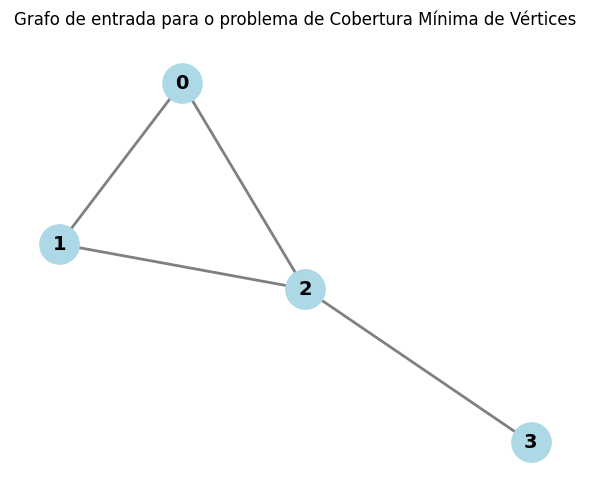

Número de vértices: 4
Número de arestas: 4
Arestas: [(0, 1), (0, 2), (1, 2), (2, 3)]


In [ ]:
# ============================================================
# Definição do grafo e visualização
# ============================================================

# Lista de arestas (u, v). Cada tupla indica uma aresta ligando
# os vértices u e v no grafo.
# Grafo com 4 vértices: 0, 1, 2, 3
# Arestas: 0-1, 1-2, 2-0 (triângulo) + 2-3 (extensão)
edges = [(0, 1), (1, 2), (2, 0), (2, 3)]

# Cria um grafo não-direcionado usando NetworkX
graph = nx.Graph(edges)

# Configuração da visualização
fig, ax = plt.subplots(1, 1, figsize=(6, 5))

# spring_layout: posiciona nós usando modelo de forças ("molas")
# seed=1: garante reprodutibilidade do layout
positions = nx.spring_layout(graph, seed=1)

# Desenha o grafo com rótulos nos vértices
nx.draw(graph, with_labels=True, pos=positions, ax=ax,
        node_color='lightblue', node_size=800,
        font_size=14, font_weight='bold', edge_color='gray', width=2)

ax.set_title("Grafo de entrada para o problema de Cobertura Mínima de Vértices",
             fontsize=12, pad=15)

plt.tight_layout()
plt.show()

print(f"Número de vértices: {graph.number_of_nodes()}")
print(f"Número de arestas: {graph.number_of_edges()}")
print(f"Arestas: {list(graph.edges())}")

In [ ]:
# ============================================================
# Construção do problema: Hamiltonianos do QAOA
# ============================================================

# qaoa.min_vertex_cover() constrói automaticamente dois Hamiltonianos:
#
# cost_h (Hamiltoniano de custo):
#   Codifica a função objetivo do vertex cover:
#   - Penaliza vértices selecionados (queremos minimizar o número de vértices)
#   - Penaliza arestas descobertas (para cada aresta (u,v), não pode ter x_u=0 e x_v=0)
#   Tipicamente escrito como:
#   H_C = A * Σ_{(u,v)∈E} (1-x_u)(1-x_v) + B * Σ_i x_i
#   onde A >> B para garantir que cobertura válida seja preferida
#
# mixer_h (Hamiltoniano misturador):
#   Hamiltoniano padrão tipo soma de Pauli-X:
#   H_M = Σ_i X_i
#   Responsável por explorar o espaço de soluções (superposição de estados)
#
# constrained=False:
#   Usa o misturador padrão (Pauli-X) sem impor restrições estruturais.
#   As restrições são incorporadas como penalidades no Hamiltoniano de custo.
#   (constrained=True usaria um misturador que preserva a viabilidade,
#    mas é mais complexo de implementar)

cost_h, mixer_h = qaoa.min_vertex_cover(graph, constrained=False)

print("Hamiltoniano de Custo (H_C):")
print(cost_h)
print()
print("Hamiltoniano Misturador (H_M):")
print(mixer_h)
print()
print("O H_C contém termos Z e ZZ que codificam o custo e as penalidades.")
print("O H_M contém termos X que permitem explorar novos estados.")

Hamiltoniano de Custo (H_C):
0.75 * (Z(0) @ Z(1)) + 0.75 * Z(0) + 0.75 * Z(1) + 0.75 * (Z(0) @ Z(2)) + 0.75 * Z(0) + 0.75 * Z(2) + 0.75 * (Z(1) @ Z(2)) + 0.75 * Z(1) + 0.75 * Z(2) + 0.75 * (Z(2) @ Z(3)) + 0.75 * Z(2) + 0.75 * Z(3) + -1.0 * Z(0) + -1.0 * Z(1) + -1.0 * Z(2) + -1.0 * Z(3)

Hamiltoniano Misturador (H_M):
1 * X(0) + 1 * X(1) + 1 * X(2) + 1 * X(3)

O H_C contém termos Z e ZZ que codificam o custo e as penalidades.
O H_M contém termos X que permitem explorar novos estados.


In [ ]:
# ============================================================
# Definição de uma 'camada' (layer) do QAOA
# ============================================================

# No QAOA, cada camada k aplica duas evoluções unitárias em sequência:
#
# 1) Camada de Custo: U_C(γ_k) = exp(-i * γ_k * H_C)
#    - γ (gamma) controla o "quanto" o custo é impresso no estado quântico
#    - Corresponde à fase adquirida por cada estado base de acordo com seu custo
#    - Estados de menor custo ganham fases diferentes dos de maior custo
#
# 2) Camada de Mistura: U_M(β_k) = exp(-i * β_k * H_M)
#    - β (beta/alpha) controla a quantidade de "mistura" entre estados
#    - Permite transições entre diferentes soluções no espaço de busca
#    - Análogo à etapa de difusão no algoritmo de Grover

def qaoa_layer(gamma, alpha):
    # Aplica exp(-i * gamma * H_C): operador de custo
    # Equivale a uma série de rotações RZ e RZZ parametrizadas por gamma
    qaoa.cost_layer(gamma, cost_h)

    # Aplica exp(-i * alpha * H_M): operador misturador
    # Equivale a uma série de rotações RX parametrizadas por alpha
    qaoa.mixer_layer(alpha, mixer_h)

print("Função qaoa_layer() definida com sucesso!")
print("Parâmetros: gamma (custo) e alpha (mistura)")

Função qaoa_layer() definida com sucesso!
Parâmetros: gamma (custo) e alpha (mistura)


In [ ]:
# ============================================================
# Configuração do circuito: número de qubits e profundidade p
# ============================================================

# wires: índices dos qubits
# Um qubit por vértice do grafo: 4 vértices → 4 qubits
# Cada qubit representa a variável binária x_i (0=fora, 1=dentro da cobertura)
wires = range(4)

# depth (profundidade p): número de camadas custo+mistura
# p=2: duas alternâncias de camadas custo-mistura
# Maior p → melhor aproximação, mas mais portas quânticas necessárias
# Para resultados práticos em grafos simples, p=2 é suficiente
depth = 2

print(f"Qubits utilizados: {list(wires)}")
print(f"Profundidade do circuito (p): {depth}")
print(f"Total de parâmetros a otimizar: {2 * depth} (γ₁,γ₂,β₁,β₂)")

Qubits utilizados: [0, 1, 2, 3]
Profundidade do circuito (p): 2
Total de parâmetros a otimizar: 4 (γ₁,γ₂,β₁,β₂)


In [ ]:
# ============================================================
# Função que descreve o circuito parametrizado QAOA
# ============================================================

def circuit(params, **kwargs):
    """
    Circuito QAOA parametrizado.

    Estrutura:
    1. Estado inicial: superposição uniforme via Hadamard em todos os qubits
       |ψ₀⟩ = H^⊗n |0...0⟩ = (1/√2^n) Σ_z |z⟩
       Isso coloca o sistema em uma sobreposição equitativa de todas as
       possíveis soluções — o ponto de partida da busca.

    2. Camadas QAOA: aplicação alternada de custo e mistura (depth vezes)
       Para p=2: U_C(γ₁) U_M(β₁) U_C(γ₂) U_M(β₂) |ψ₀⟩

    Parâmetros:
    -----------
    params[0] : array de shape (depth,)
        Vetor de parâmetros gamma: [γ₁, γ₂, ..., γ_p]
        Controla a evolução pelo Hamiltoniano de custo em cada camada

    params[1] : array de shape (depth,)
        Vetor de parâmetros alpha/beta: [β₁, β₂, ..., β_p]
        Controla a evolução pelo Hamiltoniano misturador em cada camada
    """

    # ----- Estado inicial: superposição uniforme -----
    # Aplica Hadamard em cada qubit independentemente
    # Resultado: |+⟩^⊗n = (1/√(2^n)) Σ_{z∈{0,1}^n} |z⟩
    # = superposição equiprovável de todos os 2^n bitstrings possíveis
    for w in wires:
        qml.Hadamard(wires=w)

    # ----- Camadas QAOA -----
    # qml.layer(func, depth, params[0], params[1]) chama:
    #   qaoa_layer(params[0][0], params[1][0])  # camada 1
    #   qaoa_layer(params[0][1], params[1][1])  # camada 2
    #   ...
    # O otimizador ajusta todos esses parâmetros conjuntamente
    qml.layer(qaoa_layer, depth, params[0], params[1])


print("Circuito QAOA definido com sucesso!")
print()
print("Estrutura:")
print(f"  |0...0⟩ → H⊗{len(list(wires))} → [U_C(γᵢ) U_M(βᵢ)] × {depth} → medição")

Circuito QAOA definido com sucesso!

Estrutura:
  |0...0⟩ → H⊗4 → [U_C(γᵢ) U_M(βᵢ)] × 2 → medição


In [ ]:
# ============================================================
# Criação do dispositivo e da função de custo
# ============================================================

# Criamos o dispositivo 'default.qubit' com 4 qubits
# (um por vértice do grafo)
dev = qml.device("default.qubit", wires=wires)

# ---- Função de custo (a ser minimizada pelo otimizador clássico) ----
#
# @qml.qnode(dev): transforma a função em um 'nó quântico' executável no device
# Isso permite:
#   - Execução do circuito no simulador
#   - Cálculo automático de gradientes (via shift de parâmetros)
#   - Integração com otimizadores do PennyLane

@qml.qnode(dev)
def cost_function(params):
    """
    Função de custo quântica: retorna o valor esperado de H_C.

    O otimizador clássico irá ajustar params para minimizar:
        F(params) = ⟨ψ(params)|H_C|ψ(params)⟩

    Intuição:
    ---------
    - Quando F é grande (alta energia): o estado quântico atual representa
      principalmente soluções ruins (alto custo ou inviáveis)
    - Quando F é pequeno (baixa energia): o estado representa principalmente
      soluções boas (baixo custo e viáveis)
    - O estado ótimo concentra amplitude no ground state de H_C
    """
    # Executa o circuito QAOA com os parâmetros atuais
    circuit(params)

    # qml.expval(H): calcula ⟨ψ|H_C|ψ⟩
    # Este é o valor que queremos minimizar
    return qml.expval(cost_h)

print("Função de custo criada: F(params) = ⟨ψ(params)|H_C|ψ(params)⟩")

Função de custo criada: F(params) = ⟨ψ(params)|H_C|ψ(params)⟩


In [ ]:
# ============================================================
# Otimização clássica dos parâmetros (loop híbrido)
# ============================================================

# ---- Escolha do otimizador ----
#
# GradientDescentOptimizer: implementa o gradiente descendente padrão
#   θ(t+1) = θ(t) - η * ∇F(θ(t))
# onde η (eta) é a taxa de aprendizado (learning rate)
#
# Alternativas para problemas mais complexos:
#   - qml.AdamOptimizer(): Adam (adaptativo, convergência mais rápida)
#   - qml.NesterovMomentumOptimizer(): Gradiente com momento
#   - scipy.optimize.minimize (COBYLA, Nelder-Mead): métodos sem gradiente
optimizer = qml.GradientDescentOptimizer()

# Número de iterações do loop de otimização
steps = 70

# ---- Inicialização dos parâmetros ----
#
# params tem shape (2, depth) = (2, 2):
#   params[0] = [γ₁, γ₂]: parâmetros de custo para as 2 camadas
#   params[1] = [β₁, β₂]: parâmetros de mistura para as 2 camadas
#
# Inicialização em 0.5 é apenas um chute inicial razoável.
# A qualidade da solução final pode depender da inicialização!
#
# requires_grad=True: permite que o PennyLane calcule derivadas em relação
# a esses parâmetros usando diferenciação automática
params = np.array([[0.5, 0.5], [0.5, 0.5]], requires_grad=True)

print("Iniciando otimização...")
print(f"Parâmetros iniciais: γ={params[0]}, β={params[1]}")
print(f"Custo inicial: {cost_function(params):.4f}")
print()

# Registro para visualização
cost_history = []

# ---- Loop de otimização ----
# A cada iteração:
#   1. Executa o circuito quântico com params atuais
#   2. Calcula o gradiente ∇F(params) usando parameter-shift rule
#   3. Atualiza params: params = params - learning_rate * ∇F
for i in range(steps):
    params = optimizer.step(cost_function, params)
    cost = cost_function(params)
    cost_history.append(float(cost))

    if (i + 1) % 10 == 0:
        print(f"Iteração {i+1:3d}/{steps} | Custo: {cost:.4f} | "
              f"γ={params[0]}, β={params[1]}")

print()
print("=" * 60)
print("Otimização concluída!")
print(f"Parâmetros ótimos encontrados:")
print(f"  γ (custo):   {params[0]}")
print(f"  β (mistura): {params[1]}")
print(f"Custo final: {cost_history[-1]:.4f}")

Iniciando otimização...
Parâmetros iniciais: γ=[0.5 0.5], β=[0.5 0.5]
Custo inicial: 1.9880

Iteração  10/70 | Custo: -1.1750 | γ=[0.70532457 0.78814062], β=[0.4485698 0.7314996]
Iteração  20/70 | Custo: -1.5512 | γ=[0.62528003 0.91131929], β=[0.51801544 0.82469152]
Iteração  30/70 | Custo: -1.5712 | γ=[0.6036017  0.93623269], β=[0.52657335 0.84956174]
Iteração  40/70 | Custo: -1.5720 | γ=[0.59918507 0.94086875], β=[0.52775614 0.8544288 ]
Iteração  50/70 | Custo: -1.5720 | γ=[0.59828614 0.94177159], β=[0.5279413  0.85533283]
Iteração  60/70 | Custo: -1.5720 | γ=[0.59810166 0.94194957], β=[0.52796916 0.85549843]
Iteração  70/70 | Custo: -1.5720 | γ=[0.59806352 0.94198485], β=[0.52797281 0.85552845]

Otimização concluída!
Parâmetros ótimos encontrados:
  γ (custo):   [0.59806352 0.94198485]
  β (mistura): [0.52797281 0.85552845]
Custo final: -1.5720


---

## 8. Visualização dos Resultados

Após a otimização, analisamos:

1. **Curva de aprendizado**: como o custo evoluiu durante a otimização
2. **Distribuição de probabilidades**: quais bitstrings o circuito otimizado produz
3. **Interpretação da solução**: identificar a cobertura mínima de vértices encontrada

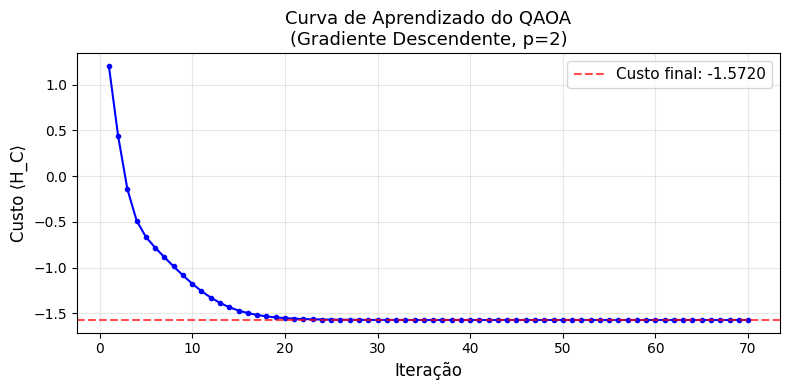

Redução do custo: 1.2055 → -1.5720
Melhora: 230.4%


In [ ]:
# ============================================================
# Curva de aprendizado: evolução do custo ao longo das iterações
# ============================================================

plt.figure(figsize=(8, 4))
plt.plot(range(1, steps + 1), cost_history, 'b-o', markersize=3, linewidth=1.5)
plt.xlabel('Iteração', fontsize=12)
plt.ylabel('Custo ⟨H_C⟩', fontsize=12)
plt.title('Curva de Aprendizado do QAOA\n(Gradiente Descendente, p=2)', fontsize=13)
plt.grid(True, alpha=0.3)
plt.axhline(y=cost_history[-1], color='r', linestyle='--',
            label=f'Custo final: {cost_history[-1]:.4f}', alpha=0.7)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"Redução do custo: {cost_history[0]:.4f} → {cost_history[-1]:.4f}")
print(f"Melhora: {((cost_history[0] - cost_history[-1]) / abs(cost_history[0])) * 100:.1f}%")

In [ ]:
# ============================================================
# Circuito para obter distribuição de probabilidades
# ============================================================

@qml.qnode(dev)
def probability_circuit(gamma, alpha):
    """
    Executa o circuito QAOA com parâmetros ótimos e retorna probabilidades.

    Parâmetros:
    -----------
    gamma : array de shape (depth,)
        Parâmetros ótimos de custo [γ₁, γ₂]
    alpha : array de shape (depth,)
        Parâmetros ótimos de mistura [β₁, β₂]

    Retorna:
    --------
    array de shape (2^n,) = (16,) para n=4 qubits
    probs[z] = |⟨z|ψ(γ*,β*)⟩|² para cada bitstring z
    """
    # Aplica o circuito com os parâmetros ótimos encontrados
    circuit([gamma, alpha])

    # qml.probs retorna todas as probabilidades de medição:
    # P(|z⟩) = |⟨z|ψ⟩|² para z = 0000, 0001, ..., 1111
    # Em um problema real com hardware quântico, faríamos shots repetidos
    # e estimaríamos as probabilidades empiricamente
    return qml.probs(wires=wires)


# Obter as probabilidades com os parâmetros ótimos
probs = probability_circuit(params[0], params[1])

print(f"Distribuição de probabilidades (16 estados para 4 qubits):")
print(f"Soma das probabilidades: {sum(probs):.6f} (deve ser ≈ 1.0)")
print()

# Converter índices para bitstrings e mostrar top-5
n_qubits = len(list(wires))
bitstrings = [format(i, f'0{n_qubits}b') for i in range(2**n_qubits)]
sorted_indices = sorted(range(len(probs)), key=lambda i: probs[i], reverse=True)

print("Top 5 bitstrings mais prováveis:")
print(f"{'Bitstring':12} {'Probabilidade':15} {'Vértices Selecionados':25} {'Cobertura Válida?'}")
print("-" * 70)

for idx in sorted_indices[:5]:
    bs = bitstrings[idx]
    p = probs[idx]
    # Vértices selecionados: posições onde o bit é '1'
    selected = [i for i, bit in enumerate(bs) if bit == '1']

    # Verifica se é uma cobertura válida
    is_valid = all(
        (u in selected) or (v in selected)
        for u, v in graph.edges()
    )

    validity_str = "✓ SIM" if is_valid else "✗ NÃO"
    print(f"{bs:12} {p:15.4f} {str(selected):25} {validity_str}")

Distribuição de probabilidades (16 estados para 4 qubits):
Soma das probabilidades: 1.000000 (deve ser ≈ 1.0)

Top 5 bitstrings mais prováveis:
Bitstring    Probabilidade   Vértices Selecionados     Cobertura Válida?
----------------------------------------------------------------------
0110                  0.2337 [1, 2]                    ✓ SIM
1010                  0.2337 [0, 2]                    ✓ SIM
1101                  0.1342 [0, 1, 3]                 ✓ SIM
1110                  0.1274 [0, 1, 2]                 ✓ SIM
1100                  0.0646 [0, 1]                    ✗ NÃO


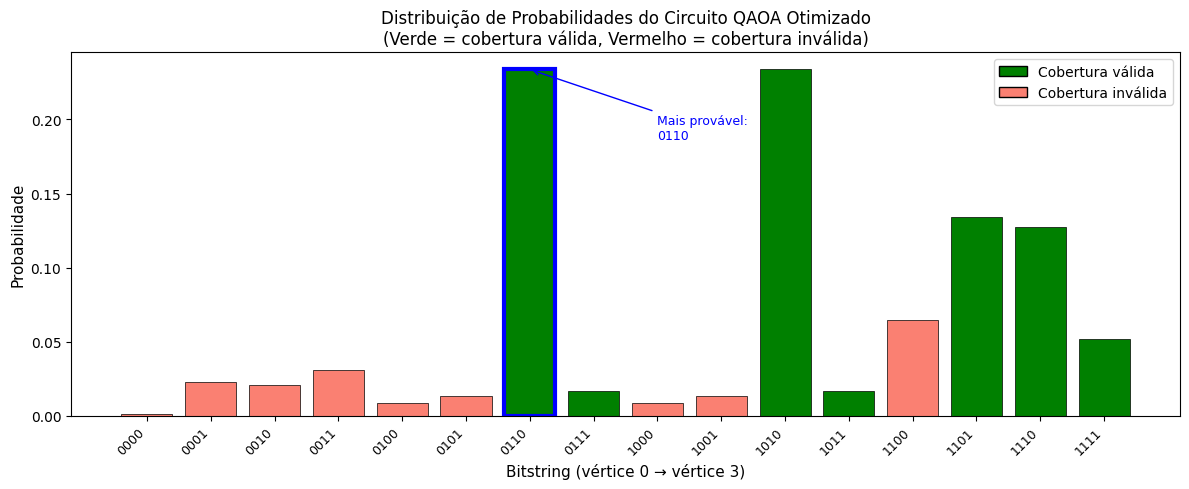

In [ ]:
# ============================================================
# Visualização da distribuição de probabilidades
# ============================================================

fig, ax = plt.subplots(figsize=(12, 5))

# Prepara as cores: verde para coberturas válidas, vermelho para inválidas
colors = []
for i, bs in enumerate(bitstrings):
    selected = [j for j, bit in enumerate(bs) if bit == '1']
    is_valid = all(
        (u in selected) or (v in selected)
        for u, v in graph.edges()
    )
    colors.append('green' if is_valid else 'salmon')

bars = ax.bar(bitstrings, probs, color=colors, edgecolor='black', linewidth=0.5)

ax.set_xlabel('Bitstring (vértice 0 → vértice 3)', fontsize=11)
ax.set_ylabel('Probabilidade', fontsize=11)
ax.set_title('Distribuição de Probabilidades do Circuito QAOA Otimizado\n'
             '(Verde = cobertura válida, Vermelho = cobertura inválida)',
             fontsize=12)
ax.set_xticks(range(len(bitstrings)))
ax.set_xticklabels(bitstrings, rotation=45, ha='right', fontsize=9)

# Destaca o bitstring de maior probabilidade
best_idx = sorted_indices[0]
bars[best_idx].set_edgecolor('blue')
bars[best_idx].set_linewidth(3)
ax.annotate(f'Mais provável:\n{bitstrings[best_idx]}',
            xy=(best_idx, probs[best_idx]),
            xytext=(best_idx + 2, probs[best_idx] * 0.8),
            fontsize=9, color='blue',
            arrowprops=dict(arrowstyle='->', color='blue'))

# Legenda
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='green', edgecolor='black', label='Cobertura válida'),
    Patch(facecolor='salmon', edgecolor='black', label='Cobertura inválida')
]
ax.legend(handles=legend_elements, fontsize=10)

plt.tight_layout()
plt.show()

RESULTADO FINAL DO QAOA
Bitstring mais provável: 0110
Probabilidade: 0.2337 (23.4%)
Vértices na cobertura: [1, 2]
Número de vértices: 2
É cobertura válida? SIM ✓



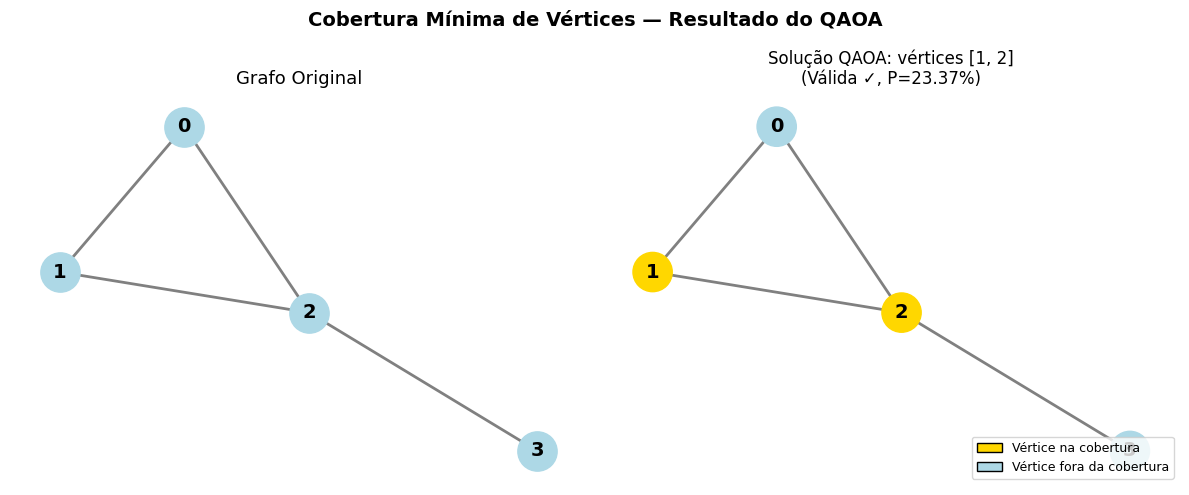

Verificação das arestas:
  Aresta (0, 1): vértice 0 ∉ cobertura, vértice 1 ∈ cobertura → ✓
  Aresta (0, 2): vértice 0 ∉ cobertura, vértice 2 ∈ cobertura → ✓
  Aresta (1, 2): vértice 1 ∈ cobertura, vértice 2 ∈ cobertura → ✓
  Aresta (2, 3): vértice 2 ∈ cobertura, vértice 3 ∉ cobertura → ✓

Resultado: Todas as arestas cobertas! ✓


In [ ]:
# ============================================================
# Interpretação da solução encontrada
# ============================================================

# Bitstring de maior probabilidade
best_bitstring = bitstrings[sorted_indices[0]]
best_prob = probs[sorted_indices[0]]
best_vertices = [i for i, bit in enumerate(best_bitstring) if bit == '1']

# Verifica cobertura
is_valid_cover = all(
    (u in best_vertices) or (v in best_vertices)
    for u, v in graph.edges()
)

print("=" * 60)
print("RESULTADO FINAL DO QAOA")
print("=" * 60)
print(f"Bitstring mais provável: {best_bitstring}")
print(f"Probabilidade: {best_prob:.4f} ({best_prob*100:.1f}%)")
print(f"Vértices na cobertura: {best_vertices}")
print(f"Número de vértices: {len(best_vertices)}")
print(f"É cobertura válida? {'SIM ✓' if is_valid_cover else 'NÃO ✗'}")
print()

# Visualiza a solução no grafo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Recalcula posições
positions = nx.spring_layout(graph, seed=1)

# --- Grafo original ---
nx.draw(graph, with_labels=True, pos=positions, ax=ax1,
        node_color='lightblue', node_size=800,
        font_size=14, font_weight='bold', edge_color='gray', width=2)
ax1.set_title("Grafo Original", fontsize=13)

# --- Grafo com solução QAOA ---
node_colors = ['gold' if v in best_vertices else 'lightblue'
               for v in graph.nodes()]

nx.draw(graph, with_labels=True, pos=positions, ax=ax2,
        node_color=node_colors, node_size=800,
        font_size=14, font_weight='bold', edge_color='gray', width=2)
ax2.set_title(f"Solução QAOA: vértices {best_vertices}\n"
              f"({'Válida ✓' if is_valid_cover else 'Inválida ✗'}, "
              f"P={best_prob:.2%})",
              fontsize=12)

# Legenda
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='gold', edgecolor='black', label='Vértice na cobertura'),
    Patch(facecolor='lightblue', edgecolor='black', label='Vértice fora da cobertura')
]
ax2.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.suptitle("Cobertura Mínima de Vértices — Resultado do QAOA",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Verifica todas as arestas
print("Verificação das arestas:")
all_covered = True
for u, v in graph.edges():
    covered = (u in best_vertices) or (v in best_vertices)
    status = "✓" if covered else "✗"
    print(f"  Aresta ({u}, {v}): vértice {u} {'∈' if u in best_vertices else '∉'} cobertura, "
          f"vértice {v} {'∈' if v in best_vertices else '∉'} cobertura → {status}")
    if not covered:
        all_covered = False

print()
print(f"Resultado: {'Todas as arestas cobertas! ✓' if all_covered else 'Cobertura incompleta! ✗'}")

---

## 9. Explorando Outro Problema Clássico: MaxCut

O algoritmo QAOA foi originalmente introduzido por Farhi, Goldstone e Gutmann em 2014, e a demonstração original de sua eficácia foi amplamente baseada na resolução do problema de **MaxCut** (Corte Máximo) em grafos regulares.


### Entendendo o MaxCut

O problema MaxCut consiste em particionar os vértices de um grafo em dois conjuntos distintos, de modo que o número de arestas (ou a soma dos pesos das arestas) que conectam vértices de conjuntos diferentes seja maximizado.

Matematicamente, se atribuirmos a cada vértice $i$ uma variável clássica $z_i \in \{-1, +1\}$ indicando a qual conjunto o vértice pertence, a função objetivo a ser maximizada é:

$$C(z) = \sum_{(i, j) \in E} \frac{1}{2}(1 - z_i z_j)$$

Na computação quântica, mapeamos as variáveis binárias para o operador de Pauli-$Z$, denotado como $Z_i$. Se dois qubits conectados por uma aresta estiverem em estados opostos (ex: $|0\rangle$ e $|1\rangle$), o termo $\frac{1}{2}(1 - Z_i Z_j)$ avalia como 1. Se estiverem no mesmo estado, avalia como 0, indicando que a aresta não foi "cortada".

### O Hamiltoniano Misturador ($H_M$)

Para explorar o espaço de busca e permitir que o estado evolua entre as diferentes possíveis soluções, aplicamos um Hamiltoniano misturador. O misturador padrão é definido como a soma das matrizes de Pauli-$X$ aplicadas a todos os qubits do sistema, $H_M = \sum_i X_i$.

In [ ]:
# ============================================================
# Construção manual dos Hamiltonianos para o MaxCut
# ============================================================

# O PennyLane oferece qaoa.max_cut(), mas construir o Hamiltoniano de
# custo e misturador manualmente é uma ótima forma de visualizar
# o mapeamento quântico-clássico na prática.

def build_maxcut_hamiltonian(graph):
    coeffs = []
    observables = []

    # Como os otimizadores clássicos do PennyLane MINIMIZAM a função por padrão,
    # precisamos inverter a lógica de maximização do MaxCut.
    # Maximizar 1/2(1 - Z_i Z_j) equivale a minimizar o produto Z_i @ Z_j.
    for u, v in graph.edges():
        coeffs.append(1.0) # Peso positivo para Z_i Z_j (favorece estados opostos com autovalor -1)
        observables.append(qml.PauliZ(u) @ qml.PauliZ(v))

    cost_h = qml.Hamiltonian(coeffs, observables)

    # Hamiltoniano Misturador: soma de Pauli-X em todos os nós do grafo.
    mixer_coeffs = [1.0] * len(graph.nodes())
    mixer_obs = [qml.PauliX(i) for i in graph.nodes()]
    mixer_h = qml.Hamiltonian(mixer_coeffs, mixer_obs)

    return cost_h, mixer_h

# Construindo usando o mesmo grafo de 4 vértices gerado anteriormente
cost_h_maxcut, mixer_h_maxcut = build_maxcut_hamiltonian(graph)

print("Hamiltoniano de Custo (MaxCut):")
print(cost_h_maxcut)
print("\nHamiltoniano Misturador (MaxCut):")
print(mixer_h_maxcut)

Hamiltoniano de Custo (MaxCut):
1.0 * (Z(0) @ Z(1)) + 1.0 * (Z(0) @ Z(2)) + 1.0 * (Z(1) @ Z(2)) + 1.0 * (Z(2) @ Z(3))

Hamiltoniano Misturador (MaxCut):
1.0 * X(0) + 1.0 * X(1) + 1.0 * X(2) + 1.0 * X(3)


---

## 10. O Efeito da Profundidade $p$ e o Loop de Otimização

Uma propriedade teórica crucial do QAOA é que, à medida que a profundidade do circuito ($p$) tende ao infinito ($\lim_{p \to \infty}$), o algoritmo garante a convergência para a solução ótima do problema. No entanto, em hardwares reais da era NISQ (propensos a ruído e descoerência), valores mais rasos como $p=1$ até $p=3$ são utilizados para equilibrar a aproximação algorítmica e a mitigação de erros físicos.

Vamos configurar o circuito do MaxCut e rodar o loop de otimização para fechar a implementação.

In [ ]:
# ============================================================
# Circuito QAOA para MaxCut e Execução do Otimizador
# ============================================================

# Definindo as camadas usando os Hamiltonianos recém-criados
def qaoa_layer_maxcut(gamma, alpha):
    qaoa.cost_layer(gamma, cost_h_maxcut)
    qaoa.mixer_layer(alpha, mixer_h_maxcut)

# Criando a função de custo para ser minimizada
@qml.qnode(dev)
def maxcut_cost_function(params):
    # 1. Preparação do estado inicial: superposição uniforme via portas Hadamard.
    for w in wires:
        qml.Hadamard(wires=w)

    # 2. Aplicação das camadas alternadas do QAOA.
    qml.layer(qaoa_layer_maxcut, depth, params[0], params[1])

    # 3. Medição do valor esperado do Hamiltoniano de Custo.
    return qml.expval(cost_h_maxcut)

# Reiniciando os parâmetros (γ, β) para o novo problema
params_maxcut = np.array([[0.5, 0.5], [0.5, 0.5]], requires_grad=True)
optimizer_maxcut = qml.GradientDescentOptimizer(stepsize=0.1)
steps_maxcut = 50

print("Iniciando otimização para o problema MaxCut...")
for i in range(steps_maxcut):
    params_maxcut = optimizer_maxcut.step(maxcut_cost_function, params_maxcut)

    if (i + 1) % 10 == 0:
        print(f"Iteração {i+1:2d}/{steps_maxcut} | Energia Esperada (Custo): {maxcut_cost_function(params_maxcut):.4f}")

print("\nOtimização concluída!")
print(f"Parâmetros ótimos encontrados (γ, β):\n{params_maxcut}")

Iniciando otimização para o problema MaxCut...
Iteração 10/50 | Energia Esperada (Custo): -0.2453
Iteração 20/50 | Energia Esperada (Custo): -0.2525
Iteração 30/50 | Energia Esperada (Custo): -0.2584
Iteração 40/50 | Energia Esperada (Custo): -0.2627
Iteração 50/50 | Energia Esperada (Custo): -0.2658

Otimização concluída!
Parâmetros ótimos encontrados (γ, β):
[[ 1.08335045  0.1271039 ]
 [-0.31878286  0.91445706]]


---

## 11. Visualizando os Resultados do MaxCut

Com os parâmetros otimizados $\gamma$ e $\beta$, podemos agora executar o circuito uma última vez para obter a **distribuição de probabilidades** dos estados finais.

No problema do MaxCut:
1. O bitstring mais provável dita a partição dos vértices (bits `0` vão para um conjunto, bits `1` vão para outro).
2. Uma aresta é considerada "cortada" se seus vértices adjacentes possuírem cores/bits diferentes.

Vamos construir o circuito de probabilidade, encontrar a melhor partição e plotar o grafo evidenciando o corte!

RESULTADO FINAL DO MAXCUT
Bitstring mais provável: 0011
Probabilidade: 0.1746 (17.5%)
Conjunto A (bit 0): [0, 1]
Conjunto B (bit 1): [2, 3]
Número de arestas cortadas: 2
Arestas cortadas: [(0, 2), (1, 2)]



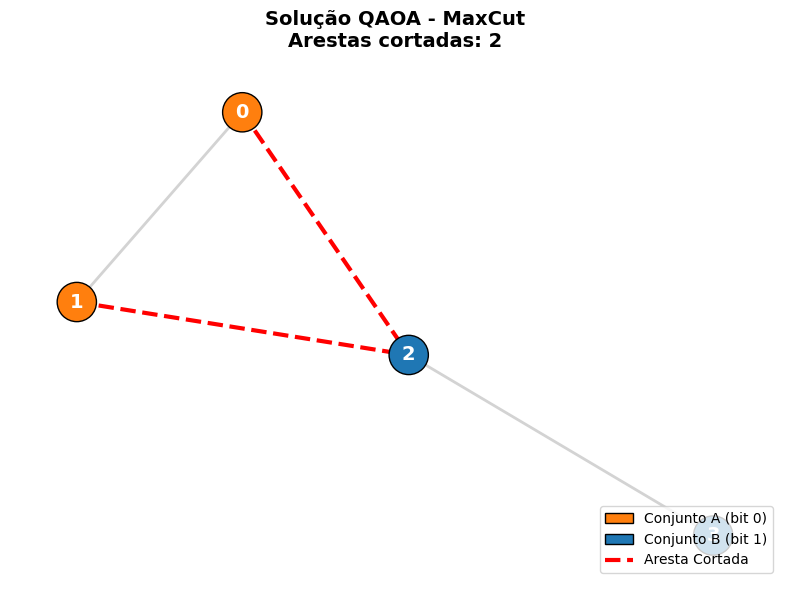

In [ ]:
# ============================================================
# Probabilidades e Visualização do Resultado (MaxCut)
# ============================================================

@qml.qnode(dev)
def maxcut_probability_circuit(gamma, alpha):
    """
    Executa o circuito do MaxCut com os parâmetros finais e retorna as probabilidades.
    """
    # Prepara o estado inicial
    for w in wires:
        qml.Hadamard(wires=w)

    # Aplica as camadas do QAOA
    qml.layer(qaoa_layer_maxcut, depth, gamma, alpha)

    # Retorna as probabilidades de todos os estados na base computacional
    return qml.probs(wires=wires)

# Obtém as probabilidades usando os parâmetros ótimos encontrados
probs_maxcut = maxcut_probability_circuit(params_maxcut[0], params_maxcut[1])

# Encontra o bitstring mais provável
best_idx_maxcut = np.argmax(probs_maxcut)
n_qubits = len(list(wires))
best_bitstring_maxcut = format(best_idx_maxcut, f'0{n_qubits}b')

print("=" * 60)
print("RESULTADO FINAL DO MAXCUT")
print("=" * 60)
print(f"Bitstring mais provável: {best_bitstring_maxcut}")
print(f"Probabilidade: {probs_maxcut[best_idx_maxcut]:.4f} ({probs_maxcut[best_idx_maxcut]*100:.1f}%)")

# Divide os vértices em dois conjuntos baseados no bitstring
set_0 = [i for i, bit in enumerate(best_bitstring_maxcut) if bit == '0']
set_1 = [i for i, bit in enumerate(best_bitstring_maxcut) if bit == '1']

print(f"Conjunto A (bit 0): {set_0}")
print(f"Conjunto B (bit 1): {set_1}")

# Identifica as arestas cortadas
cut_edges = []
for u, v in graph.edges():
    if best_bitstring_maxcut[u] != best_bitstring_maxcut[v]:
        cut_edges.append((u, v))

print(f"Número de arestas cortadas: {len(cut_edges)}")
print(f"Arestas cortadas: {cut_edges}")
print()

# ============================================================
# Visualização do Grafo Particionado
# ============================================================

fig, ax = plt.subplots(figsize=(8, 6))
positions = nx.spring_layout(graph, seed=1)

# Define cores para os nós baseando-se no conjunto a que pertencem
node_colors_maxcut = ['#ff7f0e' if i in set_0 else '#1f77b4' for i in graph.nodes()]

# Desenha os nós
nx.draw_networkx_nodes(graph, positions, ax=ax, node_color=node_colors_maxcut,
                       node_size=800, edgecolors='black')
nx.draw_networkx_labels(graph, positions, ax=ax, font_size=14,
                        font_weight='bold', font_color='white')

# Desenha as arestas não cortadas (cinza claro)
uncut_edges = [e for e in graph.edges() if e not in cut_edges and (e[1], e[0]) not in cut_edges]
nx.draw_networkx_edges(graph, positions, ax=ax, edgelist=uncut_edges,
                       edge_color='lightgray', width=2)

# Desenha as arestas cortadas (vermelho, tracejado, em destaque)
nx.draw_networkx_edges(graph, positions, ax=ax, edgelist=cut_edges,
                       edge_color='red', width=3, style='dashed')

ax.set_title(f"Solução QAOA - MaxCut\nArestas cortadas: {len(cut_edges)}",
             fontsize=14, fontweight='bold', pad=15)
ax.axis('off')

# Criação da Legenda customizada
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_elements = [
    Patch(facecolor='#ff7f0e', edgecolor='black', label='Conjunto A (bit 0)'),
    Patch(facecolor='#1f77b4', edgecolor='black', label='Conjunto B (bit 1)'),
    Line2D([0], [0], color='red', lw=3, linestyle='dashed', label='Aresta Cortada')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

---

## 12. Conclusão

Neste notebook, implementamos o **QAOA (Quantum Approximate Optimization Algorithm)** para resolver o problema de Cobertura Mínima de Vértices usando PennyLane.

### O que aprendemos:

1. **Hamiltoniano** é o operador central do QAOA: ele codifica tanto o objetivo quanto as restrições do problema como operadores quânticos de Pauli.

2. **Evolução temporal** via Trotter-Suzuki permite transformar Hamiltonianos em circuitos quânticos implementáveis em hardware real.

3. **`qml.layer()`** facilita a construção de circuitos em camadas, possibilitando controlar a profundidade $p$ do QAOA de forma limpa.

4. O **loop híbrido quântico-clássico** é o coração do QAOA:
   - O circuito quântico prepara estados parametrizados
   - O otimizador clássico ajusta os parâmetros para minimizar o custo

5. A **distribuição de probabilidades** final concentra amplitude nos bitstrings de menor custo: os melhores candidatos a solução.

6. A **aplicação no MaxCut** demonstra a versatilidade do QAOA: o problema clássico é formulado como Hamiltoniano de custo, o Hamiltoniano misturador é definido, o ansatz em camadas é implementado e o loop híbrido de otimização é executado. Ao final, a distribuição de probabilidades concentra amplitude nas melhores partições do grafo, permitindo identificar os vértices separados e as arestas efetivamente cortadas.

### Referências

- Farhi, E., Goldstone, J., & Gutmann, S. (2014). *A Quantum Approximate Optimization Algorithm*. [arXiv:1411.4028](https://arxiv.org/abs/1411.4028)
- [PennyLane QAOA — Intro to QAOA](https://pennylane.ai/qml/demos/tutorial_qaoa_intro)
- [PennyLane QAOA — QAOA for MaxCut](https://pennylane.ai/qml/demos/tutorial_qaoa_maxcut)
- [PennyLane Documentation — qaoa module](https://docs.pennylane.ai/en/stable/code/qml_qaoa.html)